In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from setup_plot import setup_plot

setup_plot()
fontsize = 8

In [19]:
tau = [None] * 5
C_u = [None] * 5

for i in range(5):
    correlation_data = pd.read_csv(fr"data/3D/two_time_velocity_correlation_n={3 * (i + 5)}.csv")

    tau[i] = correlation_data["tau"].to_numpy()
    C_u[i] = correlation_data["correlation"].to_numpy()

tau_phi = np.mean([2.920021e-02, 2.918349e-02, 2.918349e-02, 2.918349e-02, 2.918349e-02])

C:\Users\admin\AppData\Local\Temp\ipykernel_10188\2597974519.py:62: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 4)


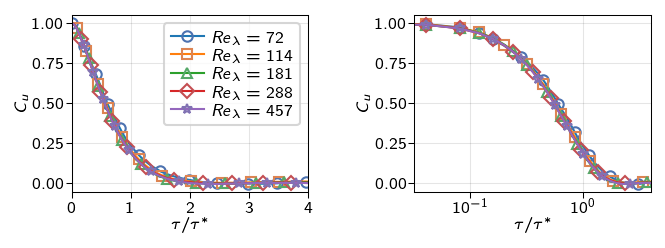

In [46]:
fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 4/2.54 / fig_width
ax_height = 3/2.54 / fig_height

colors = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B3"
]

markers = [
    "o", 
    "s",  
    "^",  
    "D",  
    "*" 
]

Re_lambda = [72, 114, 181, 288, 457]

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])

ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)

for i in range(5):
    ax.plot(tau[i] / tau_phi, C_u[i], lw=1, marker=markers[i], markersize=5, markevery=(i * 0.1 / 5, 0.1), markerfacecolor="none", markeredgecolor=colors[i], markeredgewidth=1, label=rf'$\mathit{{Re}}_\lambda={Re_lambda[i]}$')

# ax.plot(np.linspace(0, 1, 100), -1 * np.linspace(0, 1, 100) + 1.3, lw=1)    
ax.legend(ncol=1, frameon=True, labelspacing=0.2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(1, 1), loc='upper right', fontsize=fontsize)

ax.set_xlim(0, 4)
# ax.set_ylim(0, 1)
ax.set_xlabel(r'$\tau / \tau^*$', labelpad=0, fontsize=fontsize)
ax.set_ylabel(r'$C_u$', labelpad=1, fontsize=fontsize)
# ax.set_yticks(np.linspace(-1, 1, 3))
# ax.set_yticklabels([r'$10^{-1}$', r'$10^0$', r'$10^1$'])
# ax.yaxis.set_minor_formatter(NullFormatter())
# ax.yaxis.set_major_formatter(NullFormatter())
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)


# 
ax = fig.add_axes([ax_width + 0.1, 0, ax_width, ax_height])

ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)

for i in range(5):
    ax.semilogx(tau[i] / tau_phi, C_u[i], lw=1, marker=markers[i], markersize=5, markevery=(i * 0.1 / 5, 0.1), markerfacecolor="none", markeredgecolor=colors[i], markeredgewidth=1, label=rf'$\mathit{{Re}}_\lambda={Re_lambda[i]}$')

# ax.plot(np.linspace(0, 1, 100), -1 * np.linspace(0, 1, 100) + 1.3, lw=1)    

ax.set_xlim(0, 4)
# ax.set_ylim(0, 1)
ax.set_xlabel(r'$\tau / \tau^*$', labelpad=0, fontsize=fontsize)
ax.set_ylabel(r'$C_u$', labelpad=1, fontsize=fontsize)
# ax.set_yticks(np.linspace(-1, 1, 3))
# ax.set_yticklabels([r'$10^{-1}$', r'$10^0$', r'$10^1$'])
# ax.yaxis.set_minor_formatter(NullFormatter())
# ax.yaxis.set_major_formatter(NullFormatter())
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=0, width=0.5)


# 
plt.savefig(fr'figures/time_correlation.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')